## 1. Install

In [ ]:
!pip install -q findiff particles
!pip install -q https://github.com/nchopin/cubic_strat/archive/refs/heads/master.zip

## 2. The spectral estimator

In [1]:
"""
Hermite-projection / Gauss-Hermite control-variate estimators for

        I(f) = E[f(Z)],   Z ~ N(0, I_s).

Estimators implemented
----------------------
 plain      IhatM(f)   = (1/K) sum_i [ f(Z_i) - sum_{0<|a|<M} bhat_a hhat_a(Z_i) ]
 antithetic IhatM^A(f) = (1/K) sum_i [ (f(Z_i)+f(-Z_i))/2
                                       - sum_{0<|a|<M, |a| even} bhat_a hhat_a(Z_i) ]

with bhat_a from a tensorised m-point Gauss-Hermite rule.

Evaluation budget
-----------------
 plain:       n = m^s + K
 antithetic:  n = m^s + 2K
"""


import numpy as np
from numpy.polynomial.hermite_e import hermegauss


# orthonormal Hermite polynomials

def he_orthonormal(z, M):
    """hhat_n(z) = He_n(z)/sqrt(n!) for n = 0,...,M-1.

    Stable three-term recurrence
        hhat_{n+1}(z) = ( z hhat_n(z) - sqrt(n) hhat_{n-1}(z) ) / sqrt(n+1).

    Parameters
    ----------
    z : (N,) array
    M : int, number of polynomials (degrees 0..M-1)

    Returns
    -------
    (N, M) array
    """
    z = np.asarray(z, dtype=float)
    out = np.empty((z.shape[0], M))
    out[:, 0] = 1.0
    if M > 1:
        out[:, 1] = z
    for n in range(1, M - 1):
        out[:, n + 1] = (z * out[:, n] - np.sqrt(n) * out[:, n - 1]) / np.sqrt(n + 1)
    return out


def he_orthonormal_scaled(z, M):
    """hhat_n(z) * exp(-z^2/4).

    Same recurrence, rescaled initial conditions.  This factor is what keeps
    the Gauss-Hermite nodes usable: at the extreme nodes (|x| ~ 2 sqrt(m))
    hhat_n(x) overflows, while hhat_n(x) exp(-x^2/4) stays O(1).
    """
    z = np.asarray(z, dtype=float)
    sc = np.exp(-0.25 * z ** 2)
    out = np.empty((z.shape[0], M))
    out[:, 0] = sc
    if M > 1:
        out[:, 1] = z * sc
    for n in range(1, M - 1):
        out[:, n + 1] = (z * out[:, n] - np.sqrt(n) * out[:, n - 1]) / np.sqrt(n + 1)
    return out


def gauss_hermite_1d(m, M=None):
    """m-point Gauss-Hermite rule for the standard normal measure, returned in
    a form that stays accurate for large m.

    Nodes: eigenvalues of the Jacobi matrix of the probabilists' recurrence
    (zero diagonal, off-diagonal sqrt(n)). These are accurate.

    Weights: Not the squared first eigenvector components, those lose all
    relative accuracy for the tiny outer weights since they bottom out around 1e-60
    when the true value is e.g. 1e-350.  We use the
    Christoffel formula instead

        w_q = 1 / sum_{n<m} hhat_n(x_q)^2 = exp(-x_q^2/2) / S_q,
        S_q = sum_{n<m} [hhat_n(x_q) exp(-x_q^2/4)]^2,

    where every quantity on the right is O(1) or smaller.

    Returns
    -------
    x : (m,) nodes
    w : (m,) true weights, sum 1, exact on degree 2m-1
    v : (m,) compensated weights  v_q = w_q exp(x_q^2/4)
    G : (m, M) scaled basis  G[q, n] = hhat_n(x_q) exp(-x_q^2/4)   (M = m if None)
    """
    from scipy.linalg import eigh_tridiagonal
    x = eigh_tridiagonal(np.zeros(m), np.sqrt(np.arange(1, m)),
                         eigvals_only=True)
    Gfull = he_orthonormal_scaled(x, m)
    S = np.sum(Gfull ** 2, axis=1)
    ok = S > 0.0            # outer nodes underflow entirely, their true weight
    v = np.zeros(m)         # ~exp(-x^2/2) < 1e-300, so dropping them is exact
    w = np.zeros(m)         # double precision
    v[ok] = np.exp(-0.25 * x[ok] ** 2) / S[ok]
    w[ok] = np.exp(-0.50 * x[ok] ** 2) / S[ok]
    M = m if M is None else M
    return x, w, v, Gfull[:, :M]


# tensor-grid helpers

def tensor_grid(x1d, s):
    """All m^s tensor nodes as an (m^s, s) array, C-order over (i1,...,is)."""
    mesh = np.meshgrid(*([x1d] * s), indexing='ij')
    return np.stack([a.ravel() for a in mesh], axis=1)


def total_degree_mask(M, s):
    """Boolean tensor of shape (M,)*s, True where 0 < |alpha| < M."""
    idx = np.indices((M,) * s).reshape(s, -1).sum(axis=0).reshape((M,) * s)
    mask = (idx > 0) & (idx < M)
    return mask, idx


# quadrature coefficients

def quad_coefficients(f, s, m, M, return_nevals=False):
    """bhat_alpha for all alpha in {0,...,M-1}^s, by tensorised m-point GH.

        bhat_alpha = sum_q w_q f(xi_q) hhat_alpha(xi_q)

    Requires M <= m for the coefficients to be free of the worst aliasing
    where each alpha_i <= m-1, so f*hhat_alpha is integrated by a rule exact on
    degree 2m-1 whenever f is itself a polynomial of degree <= m-1.

    Returns
    -------
    b : (M,)*s array
    nevals : m^s  (only if return_nevals)
    """
    if M > m:
        raise ValueError("need M <= m (aliasing control)")
    x1d, _, v1d, H1 = gauss_hermite_1d(m, M)
    pts = tensor_grid(x1d, s)
    fv = np.asarray(f(pts), dtype=float).reshape((m,) * s)

    Wv = v1d
    for _ in range(s - 1):
        Wv = np.multiply.outer(Wv, v1d)
    A = fv * Wv
    # contract every axis in turn; tensordot appends the new axis at the end,
    # so after s contractions the axes are back in the original order.
    for _ in range(s):
        A = np.tensordot(A, H1, axes=([0], [0]))
    if return_nevals:
        return A, m ** s
    return A


def eval_expansion(b, Z, M):
    """sum_alpha b_alpha hhat_alpha(Z_i) for each sample i.

    b : (M,)*s array (already masked: unwanted alphas set to 0)
    Z : (K, s) array
    """
    K, s = Z.shape
    Hs = [he_orthonormal(Z[:, i], M) for i in range(s)]
    R = b.reshape(M, -1)                       # (M, M^{s-1})
    A = Hs[0] @ R                              # (K, M^{s-1})
    for i in range(1, s):
        A = A.reshape(K, M, -1)
        A = np.einsum('kaj,ka->kj', A, Hs[i])
    return A.ravel()


# the estimators

def hermite_estimate(f, s, m, M, K, antithetic=True, rng=None,
                     coeffs=None, return_parts=False):
    """One realisation of the (antithetic) spectral control-variate estimator.

    Parameters
    ----------
    f : callable, (N, s) -> (N,)
    s : dimension
    m : Gauss-Hermite nodes per axis (quadrature cost m^s)
    M : truncation degree, keep 0 < |alpha| < M (requires M <= m)
    K : number of Monte Carlo draws
    antithetic : use (f(Z)+f(-Z))/2 and even-degree corrections only
    coeffs : precomputed (M,)*s coefficient tensor (reused across replications)

    Returns
    -------
    dict with 'est', 'nevals'
    """
    rng = np.random.default_rng() if rng is None else rng
    if coeffs is None:
        coeffs = quad_coefficients(f, s, m, M)
    b = coeffs.copy()

    mask, deg = total_degree_mask(M, s)
    keep = mask.copy()
    if antithetic:
        keep &= (deg % 2 == 0)
    b[~keep] = 0.0                              

    Z = rng.standard_normal((K, s))
    corr = eval_expansion(b, Z, M)
    if antithetic:
        val = 0.5 * (f(Z) + f(-Z)) - corr
        nevals = m ** s + 2 * K
    else:
        val = f(Z) - corr
        nevals = m ** s + K
    est = float(np.mean(val))
    out = {'est': est, 'nevals': nevals, 'm': m, 'M': M, 'K': K}
    if return_parts:
        out['per_sample_var'] = float(np.var(val, ddof=1))
    return out


def budget_split(n, s, theta=0.5, antithetic=True, M_rule=None, m_max=None):
    """Turn a total evaluation budget n into (m, M, K).

    theta : fraction of the budget spent on the deterministic quadrature grid
            (theta * n  evaluations  ->  m = floor((theta n)^{1/s}))
    M_rule: callable m -> M.  Default M = m (the largest value allowed by the
            aliasing condition M <= m).
    """
    m = int(np.floor((theta * n) ** (1.0 / s)))
    m = max(m, 2)
    if m_max is not None:
        m = min(m, m_max)
    M = m if M_rule is None else max(1, min(m, int(M_rule(m))))
    rest = n - m ** s
    per_draw = 2 if antithetic else 1
    K = max(1, int(rest // per_draw))
    return m, M, K


# exact variance decomposition


def reference_coefficients(f, s, D, m_ref=None):
    """High-accuracy b_alpha for |alpha_i| < D, used as a stand-in for the exact
    Hermite coefficients.  Uses a much finer GH rule than the estimator does."""
    if m_ref is None:
        m_ref = max(4 * D, 200)
    return quad_coefficients(f, s, m_ref, D)


def variance_decomposition(b_ref, bhat, M, s, antithetic=True):
    """K * Var of the estimator, split into truncation and aliasing parts.

        K * Var =  sum_{|a| >= M} b_a^2      (truncation / tail of the series)
                 + sum_{0<|a|<M} (b_a - bhat_a)^2   (aliasing of retained coeffs)

    restricted to even |a| in the antithetic case.  b_ref must be at least as
    large as bhat in every axis.
    """
    D = b_ref.shape[0]
    _, deg_ref = total_degree_mask(D, s)
    sel = np.ones_like(deg_ref, dtype=bool)
    sel[(0,) * s] = False
    if antithetic:
        sel &= (deg_ref % 2 == 0)

    trunc = float(np.sum(b_ref[sel & (deg_ref >= M)] ** 2))

    pad = np.zeros_like(b_ref)
    sl = tuple(slice(0, M) for _ in range(s))
    pad[sl] = bhat
    inner = sel & (deg_ref > 0) & (deg_ref < M)
    alias = float(np.sum((b_ref[inner] - pad[inner]) ** 2))
    return {'truncation': trunc, 'aliasing': alias, 'total': trunc + alias}


## 3. Test integrands and Chopin--Gerber wrappers

In [2]:
"""
Test integrands for  I(f) = E[f(Z)],  Z ~ N(0, I_s),  together with the two
wrappers needed to make the Chopin-Gerber (2022) estimators attack the same
integral on [0,1]^s.

Two routes to a CG baseline
---------------------------
(A) Inverse-cdf transform.   Since Z_i = Phi^{-1}(U_i),

        E[f(Z)] = int_{[0,1]^s} f(Phi^{-1}(u)) du =: I(g),   g = f o Phi^{-1}.

    Feed g to `cubic_strat.core.estimate` (the non-vanishing estimator).
    This is the cleanest head-to-head. Identical integral, and CG's own
    evaluation count n = 3k^s.
    g is generally not in C^r([0,1]^s) with bounded derivatives, because
    Phi^{-1} blows up at the boundary.
(B) CG's method for R^s integrals (their Prop. 1, Section 3.3). Write
    I = int_{R^s} G(x) dx with G(x) = f(x) phi(x), and push it to [0,1]^s
    through the Student-like map psi_s, giving a vanishing integrand for
    cubic_strat.core.vanish_estimates.

Every integrand takes an (N, s) array and returns an (N,) array.
"""

import numpy as np
from scipy.stats import norm
from scipy.special import erfc

SQ2PI = np.sqrt(2.0 * np.pi)


# integrands

def _col(u):
    return u if u.ndim > 1 else u[:, None]


class Target:
    def __init__(self, name, f, truth, s, smooth, label):
        self.name, self.f, self.truth, self.s = name, f, truth, s
        self.smooth = smooth     # largest r with f in G^r(gamma), informally
        self.label = label       # for plot titles

    def __call__(self, z):
        return self.f(_col(np.asarray(z, dtype=float)))


def make_targets(s):
    """Dictionary of test problems in dimension s."""
    t = {}

    t['sin'] = Target(
        'sin',
        lambda z: np.sum(np.sin(z + 1.0), axis=1),
        s * np.sin(1.0) * np.exp(-0.5), s,
        np.inf, r'$f=\sum_i \sin(z_i+1)$  (analytic)')

    t['invquad'] = Target(
        'invquad',
        lambda z: np.sum(1.0 / (1.0 + z ** 2), axis=1),
        s * np.sqrt(np.pi / 2.0) * np.exp(0.5) * erfc(1.0 / np.sqrt(2.0)), s,
        np.inf, r'$f=\sum_i (1+z_i^2)^{-1}$  ($C^\infty$, bounded)')

    t['exp'] = Target(
        'exp',
        lambda z: np.sum(np.exp(z), axis=1),
        s * np.exp(0.5), s,
        np.inf, r'$f=\sum_i e^{z_i}$  (unbounded derivatives)')

    t['relu3'] = Target(
        'relu3',
        lambda z: np.sum(np.maximum(z, 0.0) ** 3, axis=1),
        s * 2.0 / SQ2PI, s,
        3, r'$f=\sum_i (z_i)_+^3$  ($\partial^3\in L^2$, $\partial^4\notin$)')

    t['abs'] = Target(
        'abs',
        lambda z: np.sum(np.abs(z), axis=1),
        s * np.sqrt(2.0 / np.pi), s,
        1, r'$f=\sum_i |z_i|$  ($\partial^1\in L^2$, $\partial^2\notin$)')

    # Shifted versions of the two non-smooth targets. The kink of |z| and of
    # (z)_+^3 sits at z = 0, which under both transforms lands on u = 1/2
    # a cell boundary of the CG stratification whenever k is even.
    
    from scipy.integrate import quad as _quad
    _shift = 0.3

    def _tr(g):
        val, _ = _quad(lambda z: g(z) * norm.pdf(z), -15, 15, limit=500)
        return s * val

    t['relu3_shift'] = Target(
        'relu3_shift',
        lambda z: np.sum(np.maximum(z - _shift, 0.0) ** 3, axis=1),
        _tr(lambda z: max(z - _shift, 0.0) ** 3), s,
        3, r'$f=\sum_i (z_i-0.3)_+^3$  (kink off-grid)')

    t['abs_shift'] = Target(
        'abs_shift',
        lambda z: np.sum(np.abs(z - _shift), axis=1),
        _tr(lambda z: abs(z - _shift)), s,
        1, r'$f=\sum_i |z_i-0.3|$  (kink off-grid)')

    if s >= 2:
        t['sin_mixed'] = Target(
            'sin_mixed',
            lambda z: np.sin(np.sum(z, axis=1) + 1.0),
            np.sin(1.0) * np.exp(-0.5 * s), s,
            np.inf, r'$f=\sin(\sum_i z_i+1)$  (analytic, non-separable)')

    return t


# (A) inverse-cdf wrapper for CG's non-vanishing estimator

def invcdf_phi(target, clip=1e-15):
    """g(u) = f(Phi^{-1}(u)) on (0,1)^s, ready for cubic_strat.core.estimate."""
    def phi(u):
        u = _col(np.asarray(u, dtype=float))
        u = np.clip(u, clip, 1.0 - clip)
        return target(norm.ppf(u))
    return phi


# (B) CG's psi_s for the vanishing estimator

def psi_map(u, tau=1.5):
    """psi_1(u) = (2u-1) / (u^tau (1-u)^tau), applied coordinatewise."""
    return (2.0 * u - 1.0) / (u ** tau * (1.0 - u) ** tau)


def psi_jac(u, tau=1.5):
    """psi_1'(u) = 2/(u^tau(1-u)^tau) + tau(2u-1)^2/(u^{tau+1}(1-u)^{tau+1})."""
    a = u ** tau * (1.0 - u) ** tau
    return 2.0 / a + tau * (2.0 * u - 1.0) ** 2 / (a * u * (1.0 - u))


def vanishing_phi(target, tau=1.5, xmax=40.0):
    """f_{G,psi}(u) with G(x) = f(x) * phi_{0,I}(x); integrates to I(f).

    Values are set to 0 where |psi| exceeds xmax in any coordinate: there the
    Gaussian factor is below 1e-300 and the product 0 * inf would be a NaN.
    """
    def phi_fun(u):
        u = _col(np.asarray(u, dtype=float))
        N = u.shape[0]
        ok = np.all((u > 1e-12) & (u < 1.0 - 1e-12), axis=1)
        out = np.zeros(N)
        if not ok.any():
            return out
        uu = u[ok]
        x = psi_map(uu, tau)
        good = np.all(np.abs(x) < xmax, axis=1)
        if not good.any():
            return out
        xg = x[good]
        jac = np.prod(psi_jac(uu[good], tau), axis=1)
        dens = np.exp(-0.5 * np.sum(xg ** 2, axis=1)) / (SQ2PI ** xg.shape[1])
        idx = np.where(ok)[0][good]
        out[idx] = target(xg) * dens * jac
        return out
    return phi_fun


# a smoothness ladder

def relu_family(s, powers=(1, 2, 3, 4, 5), shift=0.3):
    """f_p(z) = sum_i (z_i - shift)_+^p.

    (z-c)_+^p has p-1 continuous derivatives; its p-th derivative is p! 1{z>c},
    which is bounded hence in L^2(gamma), while the (p+1)-th is a Dirac and is
    not.  So  f_p in G^p(gamma) \\ G^{p+1}(gamma):  the Hermite smoothness index
    is exactly r = p.  Varying p therefore sweeps r while changing nothing else,
    which is what you want for checking the predicted exponent -1/2 - r/(2s).

    shift != 0 keeps the singular point off the CG cell boundaries (u = 1/2).
    """
    from scipy.integrate import quad
    out = {}
    for p in powers:
        val, _ = quad(lambda z, p=p: max(z - shift, 0.0) ** p * norm.pdf(z),
                      shift, 20, limit=500)
        out['relu%d' % p] = Target(
            'relu%d' % p,
            (lambda z, p=p: np.sum(np.maximum(z - shift, 0.0) ** p, axis=1)),
            s * val, s, p,
            r'$f=\sum_i (z_i-%.1f)_+^{%d}$  ($r=%d$)' % (shift, p, p))
    return out


# stress families: the benchmark integrands were bounded, flat in the tails and
# infinitely smooth.  These break each of those in turn.

def tail_family(s):
    """Integrands that GROW in the tails -- the region the Hermite basis
    resolves worst.  All have finite variance under gamma (required for the
    estimator to have finite variance at all)."""
    from scipy.integrate import quad
    out = {}

    out['exp1'] = Target(
        'exp1', lambda z: np.sum(np.exp(z), axis=1),
        s * np.exp(0.5), s, np.inf,
        r'$f=\sum_i e^{z_i}$  (mild tail growth)')

    out['exp2'] = Target(
        'exp2', lambda z: np.sum(np.exp(2.0 * z), axis=1),
        s * np.exp(2.0), s, np.inf,
        r'$f=\sum_i e^{2z_i}$  (strong tail growth)')

    a = 0.15   # needs a < 1/4 for E[f^2] < infinity
    out['gauss_tail'] = Target(
        'gauss_tail', lambda z: np.sum(np.exp(a * z ** 2), axis=1),
        s / np.sqrt(1.0 - 2.0 * a), s, np.inf,
        r'$f=\sum_i e^{0.15 z_i^2}$  (near-Gaussian tail growth)')

    out['invquad'] = Target(
        'invquad', lambda z: np.sum(1.0 / (1.0 + z ** 2), axis=1),
        s * np.sqrt(np.pi / 2.0) * np.exp(0.5) * erfc(1.0 / np.sqrt(2.0)),
        s, np.inf, r'$f=\sum_i (1+z_i^2)^{-1}$  (bounded, heavy shoulders)')

    v, _ = quad(lambda z: np.sqrt(abs(z)) * norm.pdf(z), -15, 15, limit=400)
    out['sqrt'] = Target(
        'sqrt', lambda z: np.sum(np.sqrt(np.abs(z)), axis=1),
        s * v, s, 0.5, r'$f=\sum_i |z_i|^{1/2}$  (cusp, $r=1/2$)')

    return out


def nonseparable_family(s):
    
    """Integrands that do not split across coordinates, so the tensor structure
    of the quadrature and of the truncation set cannot be exploited."""
    
    from scipy.integrate import quad
    out = {}

    out['sin_sum'] = Target(
        'sin_sum', lambda z: np.sin(np.sum(z, axis=1) + 1.0),
        np.sin(1.0) * np.exp(-0.5 * s), s, np.inf,
        r'$f=\sin(\sum_i z_i + 1)$  (analytic, non-separable)')

    sd = np.sqrt(s)
    v, _ = quad(lambda t: 1.0 / (1.0 + t ** 2) * norm.pdf(t, scale=sd),
                -20 * sd, 20 * sd, limit=600)
    out['invquad_sum'] = Target(
        'invquad_sum', lambda z: 1.0 / (1.0 + np.sum(z, axis=1) ** 2),
        v, s, np.inf, r'$f=(1+(\sum_i z_i)^2)^{-1}$  (non-separable)')

    w, _ = quad(lambda t: max(t - 0.3, 0.0) ** 3 * norm.pdf(t, scale=sd),
                -20 * sd, 20 * sd, limit=600)
    out['relu3_sum'] = Target(
        'relu3_sum', lambda z: np.maximum(np.sum(z, axis=1) - 0.3, 0.0) ** 3,
        w, s, 3, r'$f=(\sum_i z_i-0.3)_+^3$  (non-separable, $r=3$)')

    return out

## 4. Sweep, slope fitting, plotting

In [3]:
"""
Hermite spectral control-variate estimator  vs  Chopin-Gerber

For a common grid of evaluation budgets n, every method is run nreps times on
the same Gaussian integration problem. we record the empirical RMSE against the
exact value and fit log RMSE = b0 + b1 log n  by OLS

Methods
-------
mc            crude Monte Carlo, n draws                          (slope -1/2)
hermite       antithetic spectral estimator, m,K grown together   (this thesis)
hermite_plain non-antithetic version
hermite_fm<m> antithetic with m FIXED, only K grows               (diagnostic)
cg<r>         CG non-vanishing estimator (their eq. 9) applied to
              g(u) = f(Phi^{-1}(u)) on [0,1]^s,  n = 3k^s
cgv<r>        CG vanishing estimator (their eq. 16) applied to CG's own
              transform of  G(x) = f(x) phi(x)

Usage
-----
python run_comparison.py --s = 1 --nreps 200 --nmax 20000
python run_comparison.py --s = 2 --nreps 200 --nmax 200000 --targets relu3 abs invquad
"""

import argparse
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')




# single realisations


def run_mc(target, s, n, rng):
    Z = rng.standard_normal((n, s))
    return float(np.mean(target(Z))), n


def _cg():
    from cubic_strat import core as cg_core
    return cg_core


def run_cg_invcdf(target, s, n, r, rng):
    cg_core = _cg()
    """CG non-vanishing estimator on g = f o Phi^{-1}.  n = 3 k^s (r>=3)."""
    per = min(r, 3)
    k = int(round((n / per) ** (1.0 / s)))
    kmin = 2 if r <= 2 else (3 * r // 2 - 1)
    k = max(k, kmin)
    phi = invcdf_phi(target)
    est = cg_core.estimate(k, s, order=r, phi=phi)
    return float(est), per * k ** s


def run_cg_vanish(target, s, n, r, rng):
    cg_core = _cg()
    """CG vanishing estimator on CG's own R^s -> [0,1]^s transform."""
    k = max(2, int(round((n / r) ** (1.0 / s))))
    phi = vanishing_phi(target)
    out = cg_core.vanish_estimates(k, s, order=r, phi=phi)
    return float(out['estimates'][r - 1]), int(out['nevals'][r - 1])


# sweep

def budget_grid(nmin, nmax, npts):
    return np.unique(np.round(np.exp(np.linspace(np.log(nmin), np.log(nmax),
                                                 npts)))).astype(int)


def sweep(target, s, ns, nreps, methods, theta=0.5, m_max=800, fixed_m=None,
          seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for meth in methods:
        for n in ns:
            ests, nev = [], None
            try:
                if meth == 'mc':
                    for _ in range(nreps):
                        e, nev = run_mc(target, s, int(n), rng)
                        ests.append(e)

                elif meth.startswith('hermite'):
                    anti = not meth.endswith('plain')
                    if meth.startswith('hermite_fm'):
                        m = int(meth[len('hermite_fm'):])
                        M = m
                        K = max(1, (int(n) - m ** s) // 2)
                        if K < 5:
                            continue
                    else:
                        m, M, K = budget_split(int(n), s, theta=theta,
                                                  antithetic=anti, m_max=m_max)
                    b = quad_coefficients(target, s, m, M)
                    for _ in range(nreps):
                        out = hermite_estimate(target, s, m, M, K,
                                                  antithetic=anti, rng=rng,
                                                  coeffs=b)
                        ests.append(out['est'])
                        nev = out['nevals']

                elif meth.startswith('cgv'):
                    r = int(meth[3:])
                    for _ in range(nreps):
                        e, nev = run_cg_vanish(target, s, int(n), r, rng)
                        ests.append(e)

                elif meth.startswith('cg'):
                    r = int(meth[2:])
                    for _ in range(nreps):
                        e, nev = run_cg_invcdf(target, s, int(n), r, rng)
                        ests.append(e)
                else:
                    raise ValueError(meth)
            except Exception as exc:
                if 'TooSmallk' not in type(exc).__name__:
                    print('   [skip] %s n=%d: %s' % (meth, n, exc))
                continue

            e = np.asarray(ests)
            rows.append({'method': meth, 'n_target': int(n), 'n': int(nev),
                         'rmse': float(np.sqrt(np.mean((e - target.truth) ** 2))),
                         'bias': float(e.mean() - target.truth),
                         'sd': float(e.std(ddof=1)) if len(e) > 1 else np.nan,
                         'nreps': len(e)})
            print('   %-14s n=%-9d rmse=%.4e' % (meth, nev, rows[-1]['rmse']))
    return pd.DataFrame(rows)


def fit_slopes(df, target, rel_floor=1e-12, min_points=3):
    """OLS slope of log rmse on log n, discarding points at the precision floor."""
    out = []
    for meth, g in df.groupby('method'):
        g = g[g['rmse'] > rel_floor * max(abs(target.truth), 1.0)]
        g = g.sort_values('n')
        if len(g) < min_points:
            out.append({'method': meth, 'slope': np.nan, 'npts': len(g),
                        'note': 'hit machine precision'})
            continue
        x, y = np.log(g['n'].values), np.log(g['rmse'].values)
        b1, b0 = np.polyfit(x, y, 1)
        out.append({'method': meth, 'slope': b1, 'intercept': b0,
                    'npts': len(g), 'note': ''})
    return pd.DataFrame(out)


# plotting

def predicted_slope(method, s, target):
    """Theoretical exponent each method is supposed to hit on this target."""
    r = target.smooth
    if method == 'mc':
        return -0.5
    if method.startswith('hermite_fm'):
        return -0.5                       # M frozen: no approximation gain
    if method.startswith('hermite'):
        return np.nan if not np.isfinite(r) else -0.5 - r / (2.0 * s)
    if method.startswith('cgv') or method.startswith('cg'):
        rr = int(method.lstrip('cgv'))
        reff = rr if not np.isfinite(r) else min(rr, r)
        return -0.5 - reff / s
    return np.nan


def make_plot(df, slopes, target, s, path):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    for meth, g in df.groupby('method'):
        g = g.sort_values('n')
        sl = slopes.loc[slopes['method'] == meth, 'slope']
        sl = sl.values[0] if len(sl) else np.nan
        lab = meth if np.isnan(sl) else '%s (slope %.2f)' % (meth, sl)
        ax.loglog(g['n'], g['rmse'], marker='o', ms=3.5, lw=1.3, label=lab)

    nn = np.array(sorted(df['n'].unique()), dtype=float)
    ref = df['rmse'].max()
    for expo, sty in [(-0.5, ':'), (-0.5 - 1.0 / (2 * s), '--')]:
        ax.loglog(nn, ref * (nn / nn[0]) ** expo, sty, color='0.5', lw=1.0,
                  label=r'$n^{%.2f}$' % expo)

    ax.set_xlabel('n (evaluations of f)')
    ax.set_ylabel('RMSE')
    ax.set_title('s = %d,  %s' % (s, target.label))
    ax.legend(fontsize=7.5, loc='lower left')
    ax.grid(True, which='both', alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)




FAMILIES = {'standard': make_targets, 'relu': relu_family,
            'tail': tail_family, 'nonsep': nonseparable_family}


def experiment(s, family, targets_wanted, methods, nmin, nmax, npts, nreps,
               theta, m_max, outdir, seed=0, plot_each=True):
    """One sweep: returns (rmse dataframe, slopes dataframe) and writes CSVs."""
    import os
    os.makedirs(outdir, exist_ok=True)
    T = FAMILIES[family](s)
    names = targets_wanted or list(T)
    ns = budget_grid(nmin, nmax, npts)
    all_df, all_sl = [], []
    for name in names:
        t = T[name]
        print('\n=== s=%d  %s  (truth %.12f) ===' % (s, name, t.truth))
        df = sweep(t, s, ns, nreps, methods, theta=theta, m_max=m_max, seed=seed)
        sl = fit_slopes(df, t)
        sl['predicted'] = [predicted_slope(m, s, t) for m in sl['method']]
        df['target'] = name; sl['target'] = name; sl['s'] = s
        if plot_each:
            make_plot(df, sl, t, s, os.path.join(outdir, 'rmse_s%d_%s.png' % (s, name)))
        all_df.append(df); all_sl.append(sl)
        print(sl.to_string(index=False))
    D = pd.concat(all_df); S = pd.concat(all_sl)
    D.to_csv(os.path.join(outdir, 'rmse_s%d.csv' % s), index=False)
    S.to_csv(os.path.join(outdir, 'slopes_s%d.csv' % s), index=False)
    return D, S


## RUN 1 &mdash; smoothness ladder at $s=1$Feeds **Table 3** (upper half) and the **left panel of Figure 3**. The`hermite_fm12` method is the frozen-$M$ control curve drawn in that panel.

In [4]:
D1, S1 = experiment(
    s=1, family='relu', targets_wanted=None,
    methods=['hermite', 'hermite_fm12'],
    nmin=400, nmax=12000, npts=8, nreps=200,
    theta=0.25, m_max=3000, outdir='ladder_s1', seed=0)
S1[['target', 'method', 'slope', 'predicted']]


=== s=1  relu1  (truth 0.266761242117) ===
   hermite        n=400       rmse=5.9488e-04
   hermite        n=650       rmse=2.2505e-04
   hermite        n=1056      rmse=1.7694e-04
   hermite        n=1717      rmse=9.8121e-05
   hermite        n=2792      rmse=5.9049e-05
   hermite        n=4541      rmse=1.9569e-05
   hermite        n=7381      rmse=1.2317e-05
   hermite        n=12000     rmse=5.9795e-06
   hermite_fm12   n=400       rmse=1.2339e-03
   hermite_fm12   n=650       rmse=1.0354e-03
   hermite_fm12   n=1056      rmse=8.3652e-04
   hermite_fm12   n=1718      rmse=6.2389e-04
   hermite_fm12   n=2792      rmse=4.7346e-04
   hermite_fm12   n=4540      rmse=3.7598e-04
   hermite_fm12   n=7382      rmse=2.9532e-04
   hermite_fm12   n=12000     rmse=2.3208e-04
      method     slope  intercept  npts note  predicted target  s
     hermite -1.319027   0.444866     8            -1.0  relu1  1
hermite_fm12 -0.505744  -3.619135     8            -0.5  relu1  1

=== s=1  relu2  (trut

,target,method,slope,predicted
0,relu1,hermite,-1.319027,-1.0
1,relu1,hermite_fm12,-0.505744,-0.5
0,relu2,hermite,-1.655881,-1.5
1,relu2,hermite_fm12,-0.515411,-0.5
0,relu3,hermite,-2.337180,-2.0
1,relu3,hermite_fm12,-0.502120,-0.5
0,relu4,hermite,-2.626197,-2.5
1,relu4,hermite_fm12,-0.509898,-0.5
0,relu5,hermite,-3.363669,-3.0
1,relu5,hermite_fm12,-0.495721,-0.5


## RUN 2 &mdash; smoothness ladder at $s=2$Feeds **Table 3** (lower half) and the **right panel of Figure 3**.

In [5]:
D2, S2 = experiment(
    s=2, family='relu', targets_wanted=None,
    methods=['hermite'],
    nmin=1000, nmax=200000, npts=8, nreps=200,
    theta=0.5, m_max=400, outdir='ladder_s2', seed=0)
S2[['target', 'method', 'slope', 'predicted']]


=== s=2  relu1  (truth 0.533522484234) ===
   hermite        n=1000      rmse=1.3397e-03
   hermite        n=2132      rmse=8.2921e-04
   hermite        n=4543      rmse=4.1638e-04
   hermite        n=9685      rmse=2.5683e-04
   hermite        n=20647     rmse=1.6172e-04
   hermite        n=44014     rmse=5.4924e-05
   hermite        n=93822     rmse=2.8131e-05
   hermite        n=200000    rmse=1.7093e-05
 method     slope  intercept  npts note  predicted target  s
hermite -0.849143  -0.604355     8           -0.75  relu1  2

=== s=2  relu2  (truth 0.604120410352) ===
   hermite        n=1000      rmse=8.2411e-04
   hermite        n=2132      rmse=3.2350e-04
   hermite        n=4543      rmse=9.6048e-05
   hermite        n=9685      rmse=2.8654e-05
   hermite        n=20647     rmse=1.2810e-05
   hermite        n=44014     rmse=8.5747e-06
   hermite        n=93822     rmse=4.6741e-06
   hermite        n=200000    rmse=1.3447e-06
 method     slope  intercept  npts note  predicted tar

,target,method,slope,predicted
0,relu1,hermite,-0.849143,-0.75
0,relu2,hermite,-1.166497,-1.00
0,relu3,hermite,-1.253649,-1.25
0,relu4,hermite,-1.718291,-1.50
0,relu5,hermite,-1.756780,-1.75


### Table 3 &mdash; fitted slopes and increments per derivative

In [6]:
import pandas as pd, re

rows = []
for s, path in ((1, 'ladder_s1/slopes_s1.csv'), (2, 'ladder_s2/slopes_s2.csv')):
    df = pd.read_csv(path)
    df = df[df.method == 'hermite'].copy()
    df['p'] = df.target.str.extract(r'(\d+)$').astype(int)
    df = df.sort_values('p')
    df['increment'] = -df.slope.diff()
    for _, r in df.iterrows():
        rows.append({'s': s, 'p': r.p, 'fitted': round(r.slope, 3),
                     'increment': None if pd.isna(r.increment) else round(r.increment, 3)})

T = pd.DataFrame(rows)
display(T)

,s,p,fitted,increment
0,1,1,-1.319,NaN
1,1,2,-1.656,0.337
2,1,3,-2.337,0.681
3,1,4,-2.626,0.289
4,1,5,-3.364,0.737
5,2,1,-0.849,NaN
6,2,2,-1.166,0.317
7,2,3,-1.254,0.087
8,2,4,-1.718,0.465
9,2,5,-1.757,0.038


## RUN 3 &mdash; parity check at $s=1$

In [7]:
Dp, Sp = experiment(
    s=1, family='relu', targets_wanted=None,
    methods=['hermite', 'hermite_plain'],
    nmin=400, nmax=12000, npts=8, nreps=200,
    theta=0.25, m_max=3000, outdir='ladder_s1_parity', seed=0)


=== s=1  relu1  (truth 0.266761242117) ===
   hermite        n=400       rmse=5.9488e-04
   hermite        n=650       rmse=2.2505e-04
   hermite        n=1056      rmse=1.7694e-04
   hermite        n=1717      rmse=9.8121e-05
   hermite        n=2792      rmse=5.9049e-05
   hermite        n=4541      rmse=1.9569e-05
   hermite        n=7381      rmse=1.2317e-05
   hermite        n=12000     rmse=5.9795e-06
   hermite_plain  n=400       rmse=5.1967e-04
   hermite_plain  n=650       rmse=2.5081e-04
   hermite_plain  n=1057      rmse=1.8014e-04
   hermite_plain  n=1718      rmse=1.0959e-04
   hermite_plain  n=2793      rmse=6.2416e-05
   hermite_plain  n=4541      rmse=2.1650e-05
   hermite_plain  n=7382      rmse=1.3967e-05
   hermite_plain  n=12000     rmse=6.0208e-06
       method     slope  intercept  npts note  predicted target  s
      hermite -1.319027   0.444866     8            -1.0  relu1  1
hermite_plain -1.287833   0.254092     8            -1.0  relu1  1

=== s=1  relu2  (t

In [8]:
import pandas as pd
d = pd.read_csv('ladder_s1_parity/slopes_s1.csv')
d['p'] = d.target.str.extract(r'(\d+)$').astype(int)
T = d.pivot_table(index='p', columns='method', values='slope').sort_index()
T['trend'] = [-0.5 - p/2 for p in T.index]
for m in ('hermite', 'hermite_plain'):
    T['inc_' + m] = -T[m].diff()
    T['off_' + m] = T['trend'] - T[m]
display(T.round(3))

method,hermite,hermite_plain,trend,inc_hermite,off_hermite,inc_hermite_plain,off_hermite_plain
p,,,,,,,
1,-1.319,-1.288,-1.0,NaN,0.319,NaN,0.288
2,-1.656,-1.735,-1.5,0.337,0.156,0.447,0.235
3,-2.337,-2.258,-2.0,0.681,0.337,0.523,0.258
4,-2.626,-2.765,-2.5,0.289,0.126,0.508,0.265
5,-3.364,-3.257,-3.0,0.737,0.364,0.491,0.257


## Figures 3 and 4Writes `figs/fig_ladder.png` and `figs/fig_slope_vs_r.png`. Requires RUN 1 and RUN 2 to have completed.

In [22]:
"""
Build the two ladder figures, which the per-target sweep does not produce
directly.

  Figure 3  fig_ladder.png      two panels (s=1, s=2), RMSE against n, one
                                curve per smoothness index p, plus the
                                frozen-M control curve at s=1
  Figure 4  fig_slope_vs_r.png  fitted exponent against p, with the lines
                                -1/2 - p/(2s) overlaid

Both read the CSVs written by RUN 1 and RUN 2. `load` accepts either a single
path or a list, so a sweep run in chunks can be concatenated; duplicate
(target, method, n) rows are dropped.
"""

import os
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.bbox': 'tight',
})


def load(paths):
    if isinstance(paths, str):
        paths = [paths]
    df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
    if 'n' in df.columns:
        df = df.drop_duplicates(subset=['target', 'method', 'n'])
    else:
        df = df.drop_duplicates(subset=['target', 'method'])
    return df


def r_of(target):
    m = re.search(r'(\d+)$', str(target))
    return int(m.group(1)) if m else np.nan


# Figure 3 : the ladder


def fig_ladder(d1, d2, path):
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
    cmap = plt.get_cmap('viridis')

    for ax, df, s in ((axes[0], d1, 1), (axes[1], d2, 2)):
        if df is None or df.empty:
            ax.set_visible(False)
            continue
        h = df[df['method'] == 'hermite'].copy()
        h['r'] = h['target'].map(r_of)
        rs = sorted(h['r'].dropna().unique())

        for i, r in enumerate(rs):
            g = h[h['r'] == r].sort_values('n')
            ax.loglog(g['n'], g['rmse'], marker='o', ms=3.5, lw=1.4,
                      color=cmap(i / max(len(rs) - 1, 1)),
                      label=r'$p=%d$' % r)

        # frozen-M control, if present
        fm = df[df['method'].str.startswith('hermite_fm')]
        if not fm.empty:
            tgt = fm['target'].iloc[0]
            g = fm[fm['target'] == tgt].sort_values('n')
            ax.loglog(g['n'], g['rmse'], ls='--', lw=1.6, color='crimson',
                      label=r'$M$ frozen ($r=%d$)' % r_of(tgt))

        # reference slopes -1/2 - r/(2s) anchored at the r-th curve's first point
        for i, r in enumerate(rs):
            g = h[h['r'] == r].sort_values('n')
            nn = g['n'].values.astype(float)
            if len(nn) < 2:
                continue
            expo = -0.5 - r / (2.0 * s)
            ref = g['rmse'].values[0] * (nn / nn[0]) ** expo
            ax.loglog(nn, ref, ls=':', lw=0.9, color='0.55',
                      label=r'$n^{-1/2-p/2s}$' if i == 0 else None)

        ax.set_xlabel(r'$n$ (evaluations of $f$)')
        ax.set_ylabel('RMSE')
        ax.set_title(r'$s=%d$' % s)
        ax.grid(True, which='both', alpha=0.25)
        ax.legend(loc='lower left', ncol=2)

    fig.tight_layout()
    fig.savefig(path)
    plt.close(fig)
    print('wrote', path)


# Figure 4 : fitted exponent against p

def fig_slope_vs_r(s1, s2, path):
    fig, ax = plt.subplots(figsize=(6.0, 4.4))
    marks = {1: 'o', 2: 's'}
    cols = {1: 'tab:blue', 2: 'tab:orange'}

    for s, df in ((1, s1), (2, s2)):
        if df is None or df.empty:
            continue
        g = df[df['method'] == 'hermite'].copy()
        g['r'] = g['target'].map(r_of)
        g = g.dropna(subset=['r', 'slope']).sort_values('r')
        ax.plot(g['r'], g['slope'], marker=marks[s], ms=6, lw=0, color=cols[s],
                label=r'fitted, $s=%d$' % s)

        rr = np.linspace(g['r'].min() - 0.2, g['r'].max() + 0.2, 50)
        ax.plot(rr, -0.5 - rr / (2.0 * s), ls='--', lw=1.3, color=cols[s],
                label=r'$-\frac{1}{2}-\frac{r}{2s}$, $s=%d$' % s)

    ax.set_xlabel(r'smoothness index $r$')
    ax.set_ylabel('fitted RMSE-vs-$n$ slope')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='lower left')
    fig.tight_layout()
    fig.savefig(path)
    plt.close(fig)
    print('wrote', path)


def build_figures(s1_rmse, s2_rmse, s1_slopes, s2_slopes, outdir='figs'):
    os.makedirs(outdir, exist_ok=True)
    d1, d2 = load(s1_rmse), load(s2_rmse)
    t1, t2 = load(s1_slopes), load(s2_slopes)
    fig_ladder(d1, d2, os.path.join(outdir, 'fig_ladder.pdf'))
    fig_ladder(d1, d2, os.path.join(outdir, 'fig_ladder.png'))
    fig_slope_vs_r(t1, t2, os.path.join(outdir, 'fig_slope_vs_r.pdf'))
    fig_slope_vs_r(t1, t2, os.path.join(outdir, 'fig_slope_vs_r.png'))

wrote figs\fig_ladder.pdf
wrote figs\fig_ladder.png
wrote figs\fig_slope_vs_r.pdf
wrote figs\fig_slope_vs_r.png


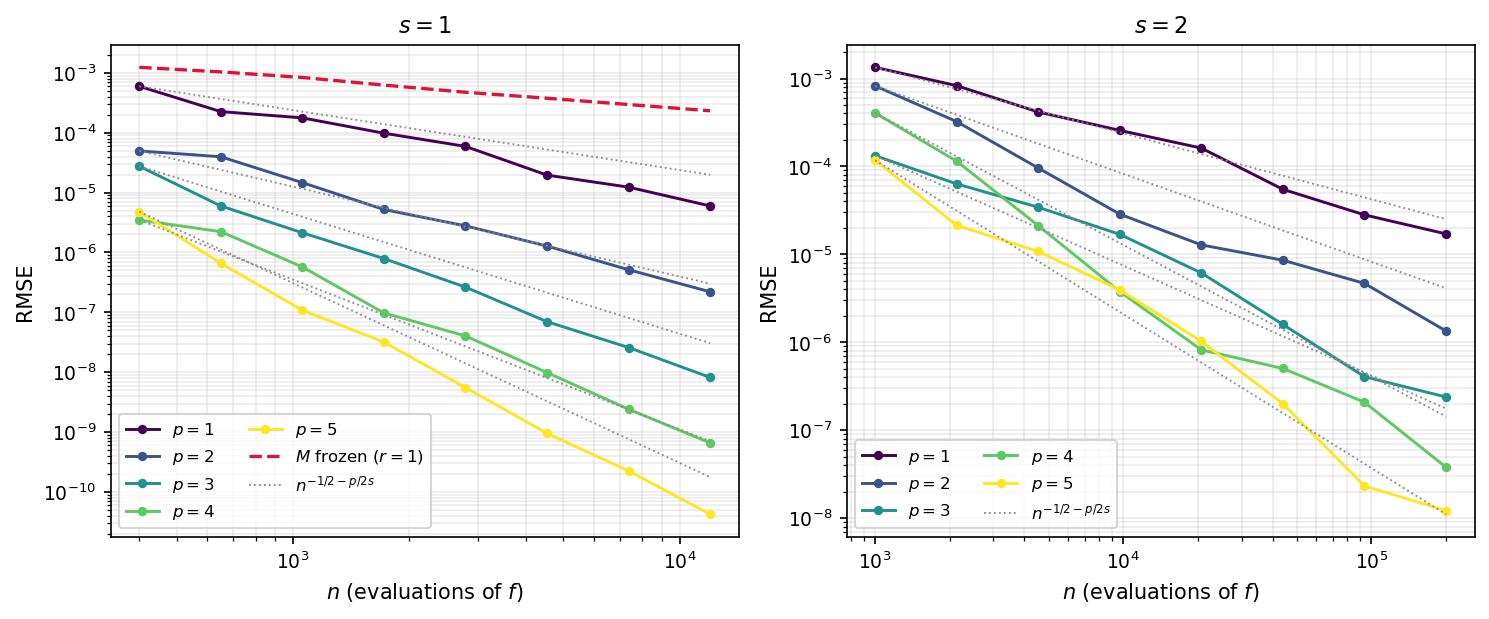

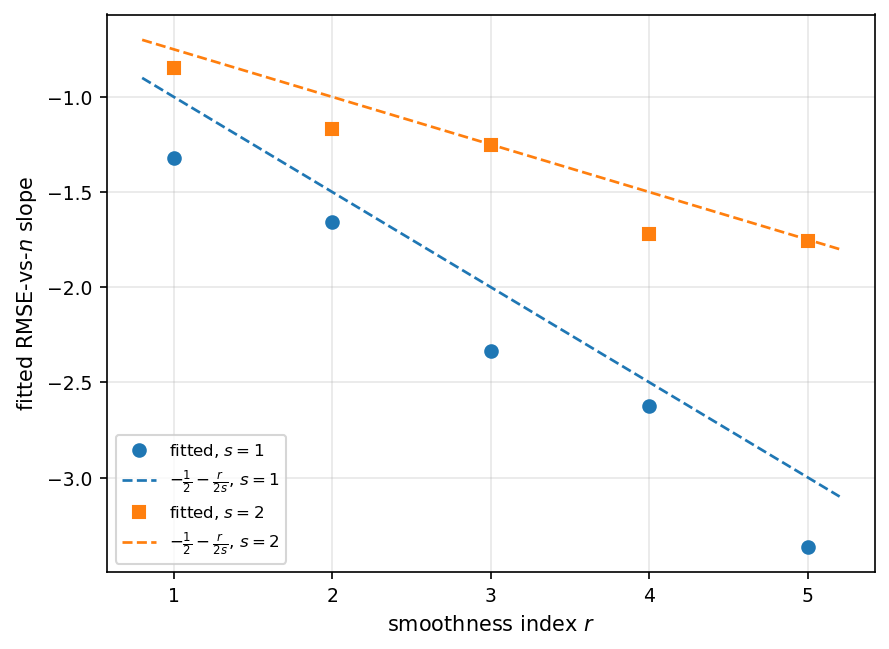

In [23]:
build_figures('ladder_s1/rmse_s1.csv', 'ladder_s2/rmse_s2.csv',
              'ladder_s1/slopes_s1.csv', 'ladder_s2/slopes_s2.csv')
from IPython.display import Image, display
display(Image('figs/fig_ladder.png')); display(Image('figs/fig_slope_vs_p.png'))

## RUN 4 &mdash; Chopin--Gerber test problems Feeds **Table 2** and **Figure 2** (`chopin_bench/dick1D.png`, `dick2D.png`,`dick3D.png`).

In [11]:
"""
Chopin-Gerber's own benchmark, with the Hermite estimator dropped in.

Their test problems are integrals over [0,1]^s:

        I(f) = int_{[0,1]^s} f(u) du.

The Hermite estimator is defined against the Gaussian measure, so it attacks the
identical integral through the probability integral transform  u = Phi(z):

        I(f) = E[ F(Z) ],   F(z) := f(Phi(z)),   Z ~ N(0, I_s).

Nothing about the problem changes, that is, same f, same true value, same target. Only
which measure the estimator integrates against.

Protocol is theirs (Section 5): nreps = 50 independent runs per configuration,
x-axis = number of evaluations of f, y-axis = rel-mse = mean[(est/I(f) - 1)^2],
log-log.  Their estimator is called through their own code
(cubic_strat.core.estimate) at orders r = 1, 2, 4, 6.

Usage
-----
python chopin_benchmark.py --d = 1
python chopin_benchmark.py --d = 2 --nreps 50
"""

import argparse
import os
import warnings

import numpy as np
import pandas as pd
from scipy.special import factorial
from scipy.stats import norm

warnings.filterwarnings('ignore')



# Chopin-Gerber's test problems, verbatim from nonvanish_xp/dick*D.py


def problem(d):
    if d == 1:
        return dict(
            ident='dick1D', d=1, true_val=1.0,
            title=r'$f_1(u)=ue^u$',
            phi=lambda u: (u * np.exp(u)).reshape(u.shape[0], -1).sum(axis=1))
    if d == 2:
        return dict(
            ident='dick2D', d=2, true_val=np.exp(1.) - 2.,
            title=r'$f_2(u)=u_2e^{u_1u_2}$',
            phi=lambda u: u[:, 1] * np.exp(np.prod(u, axis=-1)))
    if d == 3:
        return dict(
            ident='dick3D', d=3, true_val=np.exp(1.) - 2.5,
            title=r'$f_3(u)=u_2u_3^2e^{u_1u_2u_3}$',
            phi=lambda u: u[:, 1] * u[:, 2] ** 2 * np.exp(np.prod(u, axis=-1)))
    if d == 4:
        return dict(
            ident='dick4D', d=4, true_val=np.exp(1.) - 8. / 3.,
            title=r'$f_4(u)=u_2u_3^2u_4^3e^{u_1u_2u_3u_4}$',
            phi=lambda u: (u[:, 1] * u[:, 2] ** 2 * u[:, 3] ** 3
                           * np.exp(np.prod(u, axis=-1))))
    if d == 6:
        return dict(
            ident='dick6D', d=6,
            true_val=np.exp(1.) - np.sum(1. / factorial(np.arange(6))),
            title=r'$f_6(u)=(\prod_{i=2}^6 u_i^{i-1})e^{\prod_i u_i}$',
            phi=lambda u: np.prod([u[:, i] ** i for i in range(1, 6)], axis=0)
            * np.exp(np.prod(u, axis=-1)))
    raise ValueError(d)


def gaussian_pullback(pb):
    """F(z) = f(Phi(z)); same integral, Gaussian measure."""
    f = pb['phi']

    def F(z):
        z = np.asarray(z, dtype=float)
        if z.ndim == 1:
            z = z[:, None]
        return np.asarray(f(norm.cdf(z))).ravel()
    return F


# the two estimators

def cg_run(pb, n, r):
    from cubic_strat import core as cg_core
    """Their estimator, their code.  n = min(r,3) * k^d."""
    per = min(r, 3)
    k = max(int(round((n / per) ** (1.0 / pb['d']))),
            2 if r <= 2 else 3 * r // 2 - 1)
    est = cg_core.estimate(k, pb['d'], order=r, phi=pb['phi'])
    return float(est), per * k ** pb['d']


def hermite_run(F, d, n, theta, m_max, rng, cache):
    """The Hermite estimator.  n = m^d + 2K."""
    m, M, K = budget_split(int(n), d, theta=theta, m_max=m_max)
    key = (m, M)
    if key not in cache:
        cache[key] = quad_coefficients(F, d, m, M)
    out = hermite_estimate(F, d, m, M, K, antithetic=True, rng=rng,
                              coeffs=cache[key])
    return out['est'], out['nevals'], m, M, K



def sweep_bench(pb, ns, nreps, orders, theta, m_max, seed=0):
    rng = np.random.default_rng(seed)
    F = gaussian_pullback(pb)
    truth = pb['true_val']
    rows, cache = [], {}

    for r in orders:
        for n in ns:
            try:
                ests, nev = [], None
                for _ in range(nreps):
                    e, nev = cg_run(pb, n, r)
                    ests.append(e)
            except Exception as exc:
                if 'TooSmallk' not in type(exc).__name__:
                    print('   [skip] CG r=%d: %s' % (r, exc))
                    break
                continue
            except NotImplementedError as exc:
                print('   [skip] CG r=%d: %s' % (r, exc))
                break
            e = np.asarray(ests)
            rows.append({'method': 'CG r=%d' % r, 'family': 'CG', 'r': r,
                         'n': nev, 'rel_mse': float(np.mean((e / truth - 1.) ** 2)),
                         'rmse': float(np.sqrt(np.mean((e - truth) ** 2)))})
            print('   CG r=%-2d n=%-9d rel-mse=%.4e' % (r, nev, rows[-1]['rel_mse']))

    for n in ns:
        ests, nev, info = [], None, None
        for _ in range(nreps):
            e, nev, m, M, K = hermite_run(F, pb['d'], n, theta, m_max, rng, cache)
            ests.append(e)
            info = (m, M, K)
        e = np.asarray(ests)
        rows.append({'method': 'Hermite', 'family': 'Hermite', 'r': np.nan,
                     'n': nev, 'rel_mse': float(np.mean((e / truth - 1.) ** 2)),
                     'rmse': float(np.sqrt(np.mean((e - truth) ** 2))),
                     'm': info[0], 'M': info[1], 'K': info[2]})
        print('   Hermite  n=%-9d rel-mse=%.4e   (m=%d, M=%d, K=%d)'
              % (nev, rows[-1]['rel_mse'], *info))

    return pd.DataFrame(rows)


def fit_slopes_bench(df, floor=1e-30):
    out = []
    for meth, g in df.groupby('method'):
        g = g[g['rel_mse'] > floor].sort_values('n')
        if len(g) < 3:
            out.append({'method': meth, 'slope_relmse': np.nan,
                        'npts': len(g), 'note': 'at machine precision'})
            continue
        b1, b0 = np.polyfit(np.log(g['n']), np.log(g['rel_mse']), 1)
        out.append({'method': meth, 'slope_relmse': b1,
                    'slope_rmse': b1 / 2, 'npts': len(g), 'note': ''})
    return pd.DataFrame(out)


def plot_bench(df, slopes, pb, path):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7.2, 5.2))
    cmap = plt.get_cmap('tab10')
    for i, (meth, g) in enumerate(df.groupby('method')):
        g = g.sort_values('n')
        sl = slopes.loc[slopes['method'] == meth, 'slope_relmse']
        sl = sl.values[0] if len(sl) else np.nan
        lab = meth if np.isnan(sl) else '%s  [%.2f]' % (meth, sl)
        style = dict(lw=2.2, marker='') if meth == 'Hermite' else dict(lw=1.2,
                                                                      marker='o',
                                                                      ms=3)
        ax.loglog(g['n'], np.maximum(g['rel_mse'], 1e-33),
                  color='k' if meth == 'Hermite' else cmap(i),
                  label=lab, **style)
    ax.set_xlabel('nr evaluations')
    ax.set_ylabel('rel-mse')
    ax.set_title('%s   (s = %d)' % (pb['title'], pb['d']))
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, which='both', alpha=0.25)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)


def run_benchmark(d, orders, nmin, nmax, npts, nreps, theta, m_max, outdir='chopin_bench'):
    import os
    os.makedirs(outdir, exist_ok=True)
    pb = problem(d)
    ns = np.unique(np.round(np.exp(np.linspace(np.log(nmin), np.log(nmax), npts)))).astype(int)
    print('=== %s, true value %.12f ===' % (pb['ident'], pb['true_val']))
    df = sweep_bench(pb, ns, nreps, orders, theta, m_max)
    sl = fit_slopes_bench(df)
    df.to_csv(os.path.join(outdir, '%s.csv' % pb['ident']), index=False)
    sl.to_csv(os.path.join(outdir, '%s_slopes.csv' % pb['ident']), index=False)
    plot_bench(df, sl, pb, os.path.join(outdir, '%s.png' % pb['ident']))
    sl = sl.copy()
    sl['CG_predicted'] = [(-1. - 2. * int(m.split('=')[1]) / d) if m.startswith('CG') else np.nan
                          for m in sl['method']]
    print(sl.to_string(index=False))
    return df, sl


In [12]:
df1, sl1 = run_benchmark(d=1, orders=[1, 2, 4, 6],
                         nmin=30, nmax=20000, npts=9, nreps=50,
                         theta=0.4, m_max=500)

=== dick1D, true value 1.000000000000 ===
   CG r=1  n=30        rel-mse=2.7721e-05
   CG r=1  n=68        rel-mse=2.1492e-06
   CG r=1  n=152       rel-mse=2.1404e-07
   CG r=1  n=344       rel-mse=2.3033e-08
   CG r=1  n=775       rel-mse=1.3579e-09
   CG r=1  n=1746      rel-mse=1.2624e-10
   CG r=1  n=3936      rel-mse=9.1285e-12
   CG r=1  n=8872      rel-mse=1.0666e-12
   CG r=1  n=20000     rel-mse=8.1692e-14
   CG r=2  n=30        rel-mse=4.0948e-08
   CG r=2  n=68        rel-mse=6.6058e-10
   CG r=2  n=152       rel-mse=1.4197e-11
   CG r=2  n=344       rel-mse=1.8145e-13
   CG r=2  n=776       rel-mse=3.3144e-15
   CG r=2  n=1746      rel-mse=5.2714e-17
   CG r=2  n=3936      rel-mse=9.1024e-19
   CG r=2  n=8872      rel-mse=1.9137e-20
   CG r=2  n=20000     rel-mse=3.7559e-22
   CG r=4  n=30        rel-mse=1.3786e-11
   CG r=4  n=69        rel-mse=4.6638e-15
   CG r=4  n=153       rel-mse=2.3660e-18
   CG r=4  n=345       rel-mse=7.5991e-22
   CG r=4  n=774       rel-mse=3.0

In [13]:
df2, sl2 = run_benchmark(d=2, orders=[1, 2, 4, 6],
                         nmin=100, nmax=300000, npts=9, nreps=50,
                         theta=0.5, m_max=400)

=== dick2D, true value 0.718281828459 ===
   CG r=1  n=100       rel-mse=5.2781e-05
   CG r=1  n=256       rel-mse=1.0321e-05
   CG r=1  n=729       rel-mse=9.9248e-07
   CG r=1  n=2025      rel-mse=1.1546e-07
   CG r=1  n=5476      rel-mse=1.5276e-08
   CG r=1  n=14884     rel-mse=2.7283e-09
   CG r=1  n=40401     rel-mse=2.7671e-10
   CG r=1  n=110224    rel-mse=6.8409e-11
   CG r=1  n=300304    rel-mse=6.5999e-12
   CG r=2  n=98        rel-mse=7.2758e-07
   CG r=2  n=288       rel-mse=2.5566e-08
   CG r=2  n=722       rel-mse=1.4712e-09
   CG r=2  n=2048      rel-mse=1.0173e-10
   CG r=2  n=5408      rel-mse=3.9549e-12
   CG r=2  n=14792     rel-mse=2.4068e-13
   CG r=2  n=40328     rel-mse=1.0790e-14
   CG r=2  n=110450    rel-mse=6.1899e-16
   CG r=2  n=299538    rel-mse=3.0415e-17
   CG r=4  n=108       rel-mse=9.6866e-10
   CG r=4  n=300       rel-mse=6.7704e-12
   CG r=4  n=768       rel-mse=5.3530e-14
   CG r=4  n=2028      rel-mse=2.6282e-16
   CG r=4  n=5547      rel-mse=1.7

In [14]:
df3, sl3 = run_benchmark(d=3, orders=[1, 2, 4, 6],
                        nmin=1000, nmax=200000, npts=8, nreps=50,
                        theta=0.5, m_max=200)

=== dick3D, true value 0.218281828459 ===
   CG r=1  n=1000      rel-mse=3.4510e-05
   CG r=1  n=2197      rel-mse=9.0202e-06
   CG r=1  n=4913      rel-mse=2.4206e-06
   CG r=1  n=9261      rel-mse=6.1630e-07
   CG r=1  n=19683     rel-mse=2.1730e-07
   CG r=1  n=42875     rel-mse=6.8669e-08
   CG r=1  n=91125     rel-mse=1.4271e-08
   CG r=1  n=195112    rel-mse=5.2744e-09
   CG r=2  n=1024      rel-mse=4.4738e-07
   CG r=2  n=2000      rel-mse=1.2024e-07
   CG r=2  n=4394      rel-mse=1.8731e-08
   CG r=2  n=9826      rel-mse=4.4901e-09
   CG r=2  n=21296     rel-mse=3.5643e-10
   CG r=2  n=43904     rel-mse=9.0309e-11
   CG r=2  n=93312     rel-mse=1.9453e-11
   CG r=2  n=194672    rel-mse=2.8784e-12
   CG r=4  n=1029      rel-mse=1.0247e-09
   CG r=4  n=2187      rel-mse=6.4580e-11
   CG r=4  n=3993      rel-mse=4.7638e-12
   CG r=4  n=10125     rel-mse=1.1694e-13
   CG r=4  n=20577     rel-mse=1.4969e-14
   CG r=4  n=41472     rel-mse=1.0443e-15
   CG r=4  n=98304     rel-mse=3.0

### Table 2 and the local slopes quoted in Section 4.3


======================================== s = 1


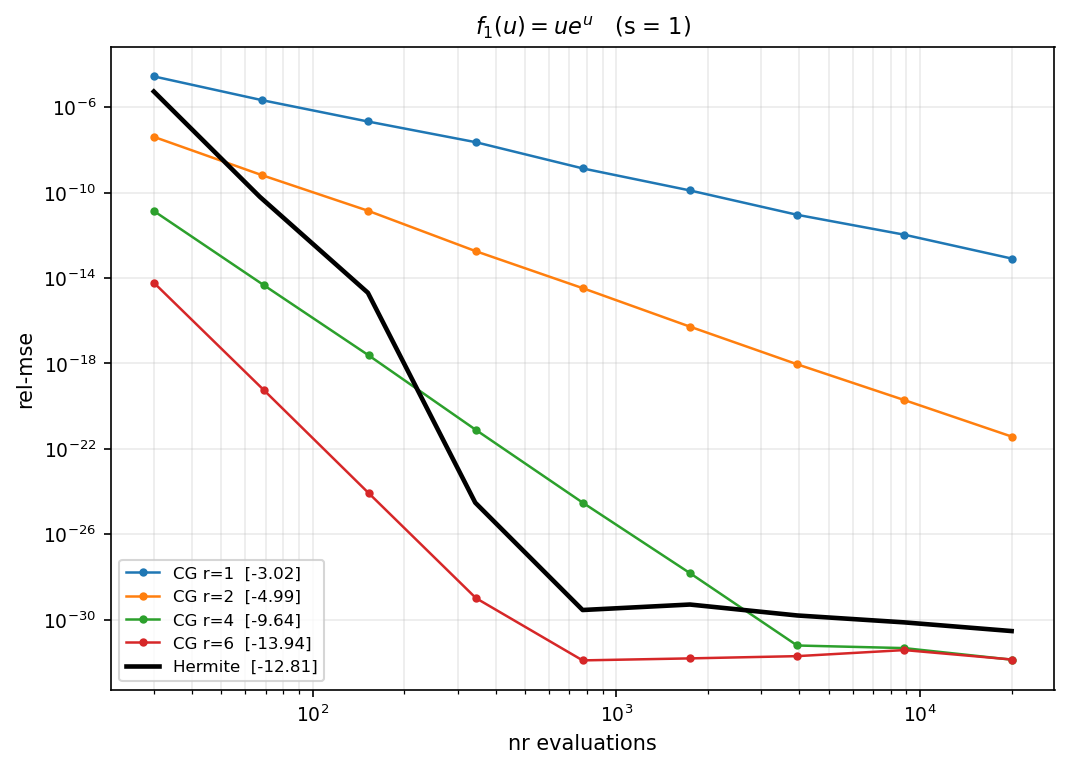

,method,slope_relmse,slope_rmse,npts,note
0,CG r=1,-3.024306,-1.512153,9,NaN
1,CG r=2,-4.991364,-2.495682,9,NaN
2,CG r=4,-9.642051,-4.821026,6,NaN
3,CG r=6,-13.936024,-6.968012,4,NaN
4,Hermite,-12.805261,-6.402631,7,NaN


local slopes: [-14.14 -12.63 -27.81 -14.23   0.73  -1.45  -0.92  -1.15]

======================================== s = 2


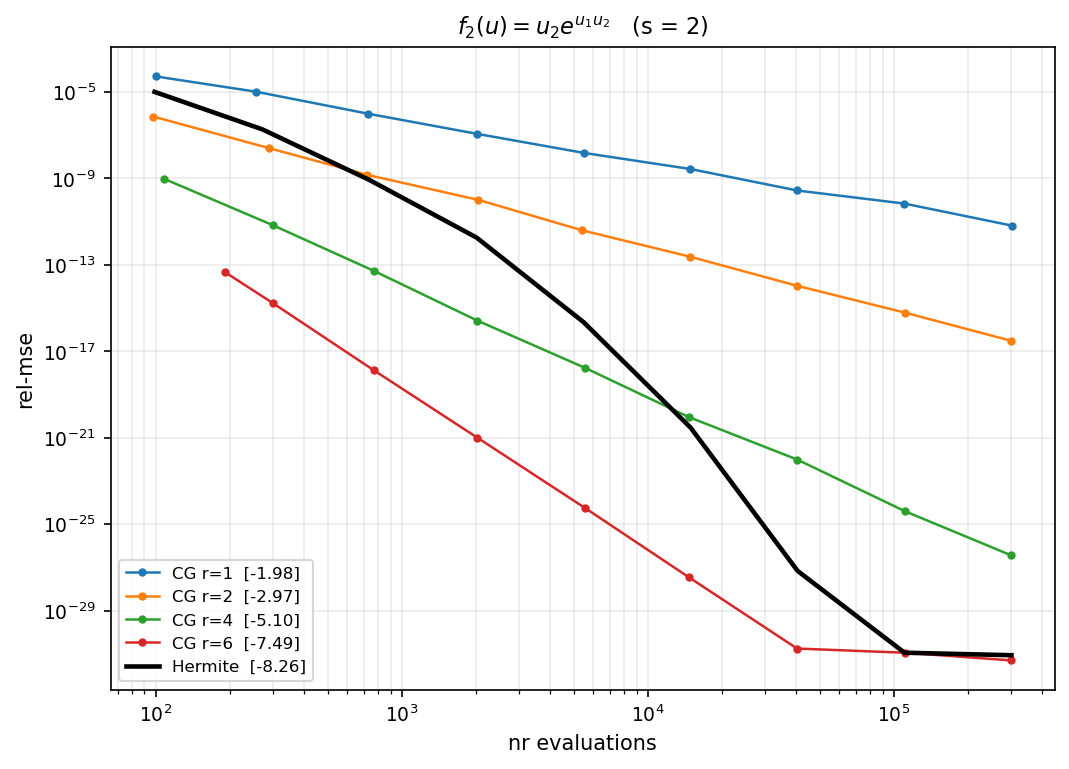

,method,slope_relmse,slope_rmse,npts,note
0,CG r=1,-1.983100,-0.991550,9,NaN
1,CG r=2,-2.966250,-1.483125,9,NaN
2,CG r=4,-5.096961,-2.548481,9,NaN
3,CG r=6,-7.487080,-3.743540,6,NaN
4,Hermite,-8.261253,-4.130626,7,NaN


local slopes: [ -3.96  -5.38  -6.12  -9.01 -11.23 -15.26  -8.72  -0.27]

======================================== s = 3


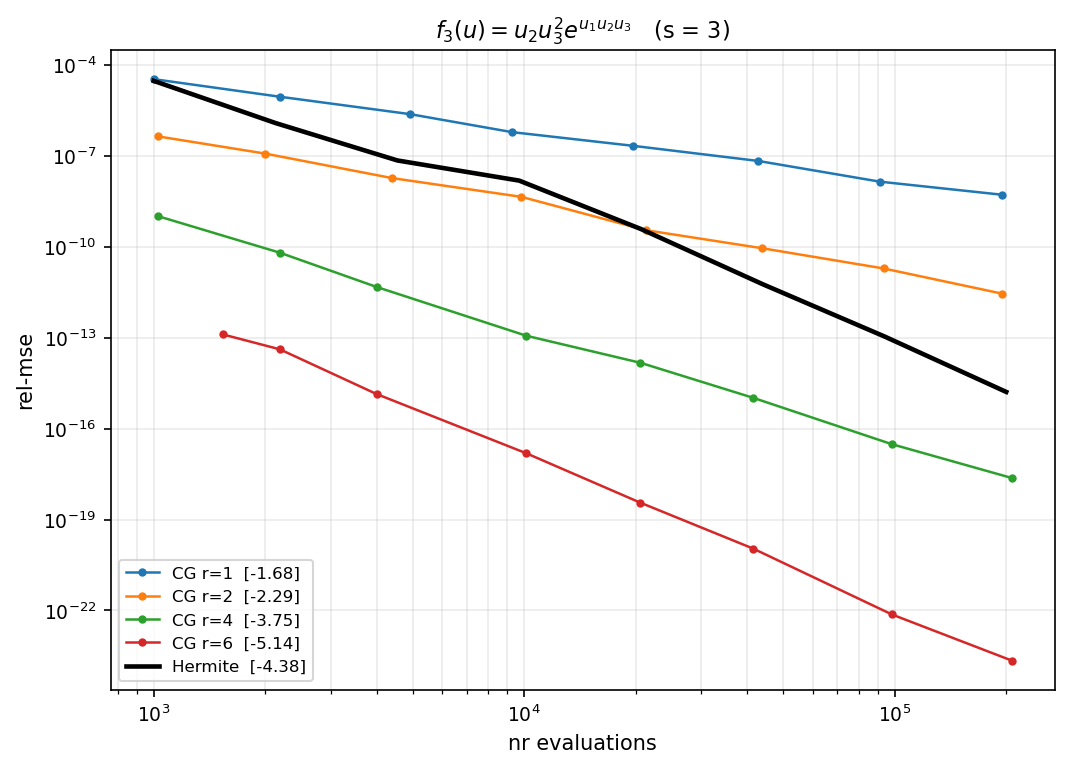

,method,slope_relmse,slope_rmse,npts,note
0,CG r=1,-1.679094,-0.839547,8,NaN
1,CG r=2,-2.292923,-1.146461,8,NaN
2,CG r=4,-3.746971,-1.873485,8,NaN
3,CG r=6,-5.137984,-2.568992,8,NaN
4,Hermite,-4.380045,-2.190023,8,NaN


local slopes: [-4.23 -3.75 -2.02 -4.86 -5.54 -5.25 -5.57]


In [24]:
from IPython.display import Image, display
import numpy as np, pandas as pd

for d in (1, 2, 3):
    print('\n' + '=' * 40, 's = %d' % d)
    display(Image('chopin_bench/dick%dD.png' % d))
    sl = pd.read_csv('chopin_bench/dick%dD_slopes.csv' % d)
    display(sl)
    df = pd.read_csv('chopin_bench/dick%dD.csv' % d)
    g = df[df.method == 'Hermite'].sort_values('n')
    print('local slopes:',
          np.round(np.diff(np.log(g.rel_mse.values)) / np.diff(np.log(g.n.values)), 2))

## RUN 5 &mdash; head-to-head on the ladder at $s=1$Feeds **Table 4**: both estimators on the same integrands

method,cgv1,cgv2,cgv4,hermite
p,,,,
1,-1.493,-1.936,-1.944,-1.319
2,-1.512,-2.476,-3.163,-1.656
3,-1.520,-2.526,-4.160,-2.337
4,-1.498,-2.509,-4.507,-2.626
5,-1.509,-2.490,-4.515,-3.364



mean gain per derivative:
method
cgv1       0.004
cgv2       0.139
cgv4       0.643
hermite    0.511
dtype: float64


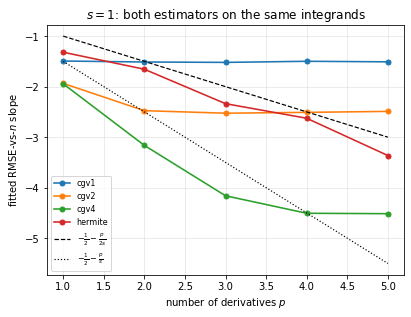

In [16]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
d = pd.read_csv('head2head_s1/slopes_s1.csv')
d['p'] = d.target.str.extract(r'(\d+)$').astype(int)
T = d.pivot_table(index='p', columns='method', values='slope').sort_index()
display(T.round(3))
print('\nmean gain per derivative:')
print((-T.diff().mean()).round(3))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
for m in T.columns:
    ax.plot(T.index, T[m], marker='o', ms=5, lw=1.6, label=m)
pp = np.array(T.index, float)
ax.plot(pp, -0.5 - pp/2, 'k--', lw=1.2, label=r'$-\frac{1}{2}-\frac{p}{2s}$')
ax.plot(pp, -0.5 - pp,   'k:',  lw=1.2, label=r'$-\frac{1}{2}-\frac{p}{s}$')
ax.set_xlabel('number of derivatives $p$')
ax.set_ylabel('fitted RMSE-vs-$n$ slope')
ax.set_title('$s=1$: both estimators on the same integrands')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.savefig('figs/head2head_s1.pdf', bbox_inches='tight')
plt.show()

## RUN 6 &mdash; PimaFeeds **Tables 6 and 7** and **Figure 5** (`pima_results/Pima2.png`,`Pima4.png`). Only $\lambda = 1.5$ is run, which is the scale reported.

In [17]:
"""Laplace approximation of the Pima logistic posterior, as in prep_pima.py."""
import numpy as np
from scipy import linalg, optimize
from particles import datasets as dts

PREDS = dts.Pima().data          # already y_i * x_i, shape (768, 9)
SCALE_PRIOR = 5.0

def logpost(beta, preds=None):
    p = PREDS if preds is None else preds
    d = np.shape(beta)[-1]
    lin = np.dot(p[:, :d], beta)
    loglik = np.sum(-np.log1p(np.exp(-lin)))
    logprior = -(0.5 / SCALE_PRIOR ** 2) * np.sum(beta ** 2)
    return logprior + loglik

def laplace(d):
    P = PREDS[:, :d]
    res = optimize.minimize(lambda b: -logpost(b), np.zeros(d), method='BFGS',
                            options={'maxiter': 1000, 'gtol': 1e-12})
    mu = res.x
    sig = 1.0 / (1.0 + np.exp(-(P @ mu)))
    H = (P * (sig * (1 - sig))[:, None]).T @ P + np.eye(d) / SCALE_PRIOR ** 2
    Sigma = linalg.inv(H)
    Cu = linalg.cholesky(Sigma, lower=False)
    return {'mu': mu, 'Cu': Cu, 'Sigma': Sigma, 'maxlp': logpost(mu)}


In [18]:
"""The Pima marginal likelihood as (a) a Gaussian integral, (b) their cube integral."""
import numpy as np


def lp_vec(X, chunk=20000):
    """Vectorised log-posterior; identical to looping logpost, ~100x faster."""
    X = np.atleast_2d(X)
    d = X.shape[1]
    P = PREDS[:, :d]
    out = np.empty(X.shape[0])
    for a in range(0, X.shape[0], chunk):
        b = X[a:a + chunk]
        lin = b @ P.T
        out[a:a + chunk] = (-np.sum(np.logaddexp(0.0, -lin), axis=1)
                            - (0.5 / SCALE_PRIOR ** 2) * np.sum(b ** 2, axis=1))
    return out

# my version
def gaussian_integrand(d, scale_prop=1.5):
    """F(z) with Z ~ N(0, I_d);  E[F(Z)] = marginal likelihood * exp(-maxlp).

    beta = mu + A z with A = scale_prop * Cu^T, so the sampling distribution of
    beta is exactly N(mu, A A^T).  F is the importance weight p(beta)/q(beta).
    """
    L = laplace(d)
    A = scale_prop * L['Cu'].T
    logdetA = np.sum(np.log(np.abs(np.diag(A))))
    const = 0.5 * d * np.log(2.0 * np.pi) + logdetA - L['maxlp']

    def F(z):
        z = np.atleast_2d(z)
        beta = L['mu'] + z @ A.T
        return np.exp(lp_vec(beta) + const + 0.5 * np.sum(z ** 2, axis=1))
    return F, L

# their version
def psi(u, t):
    umu = u * (1.0 - u)
    tm1 = 2.0 * u - 1.0
    umutau = umu ** t
    z = tm1 / umutau
    jac = 2.0 / umutau + t * tm1 ** 2 / umu ** (t + 1)
    return z, np.sum(np.log(jac), axis=1)

def cube_integrand(d, tau=1.0, scale_prop=1.5, variant='as_written'):
    """variant='as_written'  -> exactly pima_common.phi
       variant='prop1'       -> the sign/constant implied by their Proposition 1
    """
    L = laplace(d)
    Cu = L['Cu'] / scale_prop

    def phi(u):
        u = np.atleast_2d(u)
        z, ljac = psi(u, tau)
        x = L['mu'] + z @ Cu
        if variant == 'as_written':
            cst = 0.5 * np.sum(np.log(np.diag(Cu)))
            lw = lp_vec(x) - (ljac - cst) - L['maxlp']
        else:
            logdet = np.sum(np.log(np.abs(np.diag(Cu))))
            lw = lp_vec(x) + ljac + logdet - L['maxlp']
        return np.exp(lw)
    return phi


In [19]:
"""Chopin-Gerber's Pima experiment, with the spectral estimator alongside.

Protocol is theirs (Section 5.2): 50 independent runs per configuration, no exact
value available, so the reported quantity is the Relative Variance
     rel-var = Var(est) / mean(est)^2 .
"""
import os, warnings
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')


def pima_sweep(d, ns, nreps, orders, theta, m_max, variant, scale=1.5, seed=0):
    rng = np.random.default_rng(seed)
    F, L = gaussian_integrand(d, scale_prop=scale)
    phi = cube_integrand(d, variant=variant)
    rows, cache = [], {}

    for n in ns:
        m, M, K = budget_split(int(n), d, theta=theta, m_max=m_max)
        key = (m, M)
        if key not in cache:
            cache[key] = quad_coefficients(F, d, m, M)
        est = []
        for _ in range(nreps):
            o = hermite_estimate(F, d, m, M, K, rng=rng, coeffs=cache[key])
            est.append(o['est']); nev = o['nevals']
        e = np.array(est)
        rows.append({'method': 'spectral', 'order': np.nan, 'nevals': nev,
                     'mean': e.mean(), 'relvar': e.var(ddof=1) / e.mean() ** 2,
                     'm': m, 'M': M, 'K': K})
        print('  spectral n=%-9d mean=%.6e rel-var=%.3e (m=%d,M=%d,K=%d)'
              % (nev, e.mean(), rows[-1]['relvar'], m, M, K))

    from cubic_strat import core as cg_core
    for r in orders:
        for n in ns:
            k = max(2, int(round((n / r) ** (1.0 / d))))
            est, nev = [], None
            try:
                for _ in range(nreps):
                    out = cg_core.vanish_estimates(k, d, order=r, phi=phi)
                    est.append(float(out['estimates'][r - 1]))
                    nev = int(out['nevals'][r - 1])
            except Exception as exc:
                print('   [skip] CG r=%d k=%d: %s' % (r, k, exc)); continue
            e = np.array(est)
            rows.append({'method': 'CG vanishing', 'order': r, 'nevals': nev,
                         'mean': e.mean(), 'relvar': e.var(ddof=1) / e.mean() ** 2})
            print('  CG r=%-2d  n=%-9d mean=%.6e rel-var=%.3e'
                  % (r, nev, e.mean(), rows[-1]['relvar']))
    return pd.DataFrame(rows)


def plot_pima(df, d, path):
    import matplotlib; matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.size': 9, 'figure.dpi': 150, 'savefig.bbox': 'tight'})
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    cmap = plt.get_cmap('tab10')
    for i, (r, g) in enumerate(df[df.method == 'CG vanishing'].groupby('order')):
        g = g.sort_values('nevals')
        ax.loglog(g['nevals'], g['relvar'], lw=1.4, marker='o', ms=3,
                  color=cmap(i), label='CG vanishing, $r=%d$' % r)
    g = df[df.method == 'spectral'].sort_values('nevals')
    ax.loglog(g['nevals'], g['relvar'], lw=2.6, color='k', marker='s', ms=4,
              label='spectral estimator')
    ax.set_xlabel('nr evaluations'); ax.set_ylabel('rel-var')
    ax.set_title('Pima $s=%d$' % d)
    ax.grid(True, which='both', alpha=0.25); ax.legend(fontsize=7.5)
    fig.tight_layout()
    for e in ('pdf', 'png'): fig.savefig(path + '.' + e)


def run_pima(d, nmin, nmax, npts, nreps, orders, theta=0.5, m_max=400,
             variant='prop1', scale=1.5, outdir='pima_results'):
    os.makedirs(outdir, exist_ok=True)
    ns = np.unique(np.round(np.exp(np.linspace(np.log(nmin), np.log(nmax), npts)))).astype(int)
    print('=== Pima s=%d, lambda=%.1f ===' % (d, scale))
    df = pima_sweep(d, ns, nreps, orders, theta, m_max, variant, scale=scale)
    df['d'] = d; df['lam'] = scale
    df.to_csv(os.path.join(outdir, 'pima%d_lam%.1f.csv' % (d, scale)), index=False)
    plot_pima(df, d, os.path.join(outdir, 'pima%d_lam%.1f' % (d, scale)))
    return df


=== Pima s=2, lambda=1.5 ===
  spectral n=200       mean=7.531399e-02 rel-var=9.189e-05 (m=10,M=10,K=50)
  spectral n=603       mean=7.537712e-02 rel-var=2.026e-07 (m=17,M=17,K=157)
  spectral n=1820      mean=7.537839e-02 rel-var=5.213e-11 (m=30,M=30,K=460)
  spectral n=5492      mean=7.537844e-02 rel-var=3.131e-17 (m=52,M=52,K=1394)
  spectral n=16571     mean=7.537844e-02 rel-var=5.941e-27 (m=91,M=91,K=4145)
  spectral n=50000     mean=7.537844e-02 rel-var=2.684e-31 (m=158,M=158,K=12518)
  CG r=1   n=196       mean=7.534255e-02 rel-var=3.138e-04
  CG r=1   n=625       mean=7.530627e-02 rel-var=2.849e-05
  CG r=1   n=1849      mean=7.534205e-02 rel-var=3.991e-06
  CG r=1   n=5476      mean=7.538369e-02 rel-var=3.337e-07
  CG r=1   n=16641     mean=7.537824e-02 rel-var=3.453e-08
  CG r=1   n=50176     mean=7.537916e-02 rel-var=5.168e-09
  CG r=2   n=200       mean=7.535780e-02 rel-var=3.114e-05
  CG r=2   n=578       mean=7.537117e-02 rel-var=2.010e-06
  CG r=2   n=1800      mean=7.53

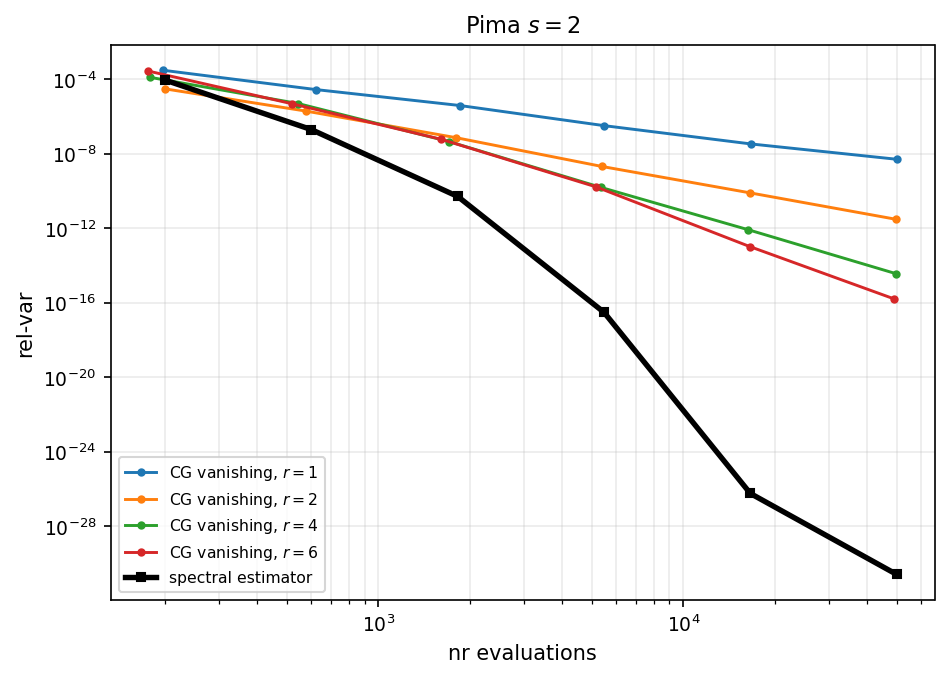

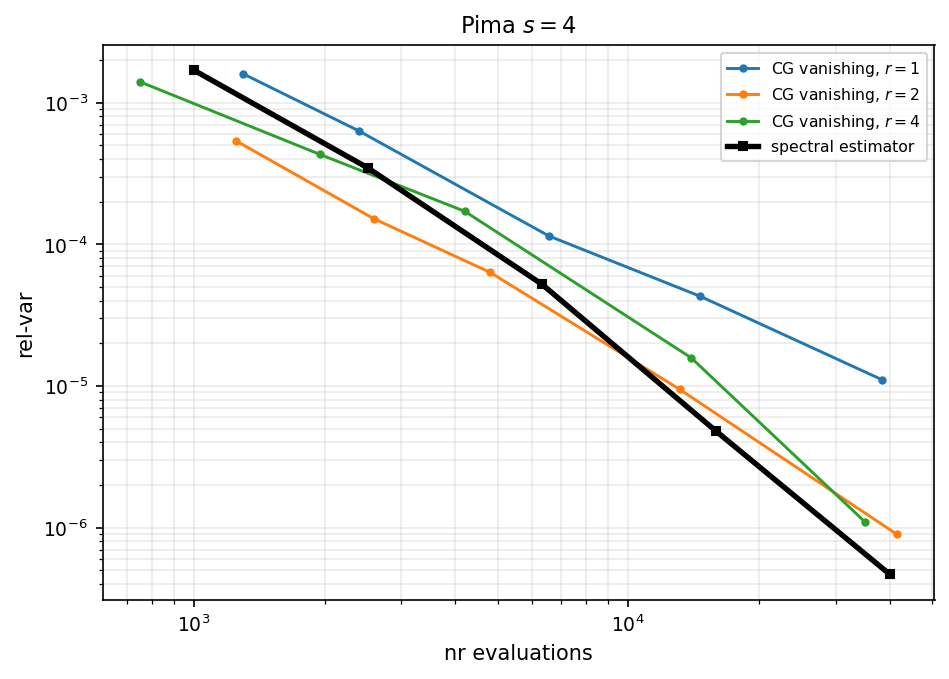

In [26]:
dfp2 = run_pima(d=2, nmin=200, nmax=50000, npts=6, nreps=50,
                orders=[1, 2, 4, 6], m_max=300)
dfp4a = run_pima(d=4, nmin=1000, nmax=40000, npts=5, nreps=50,
                 orders=[1, 2, 4], m_max=60, scale=1.5)

### Tables 6 and 7

pima_results\pima2_lam1.5.png


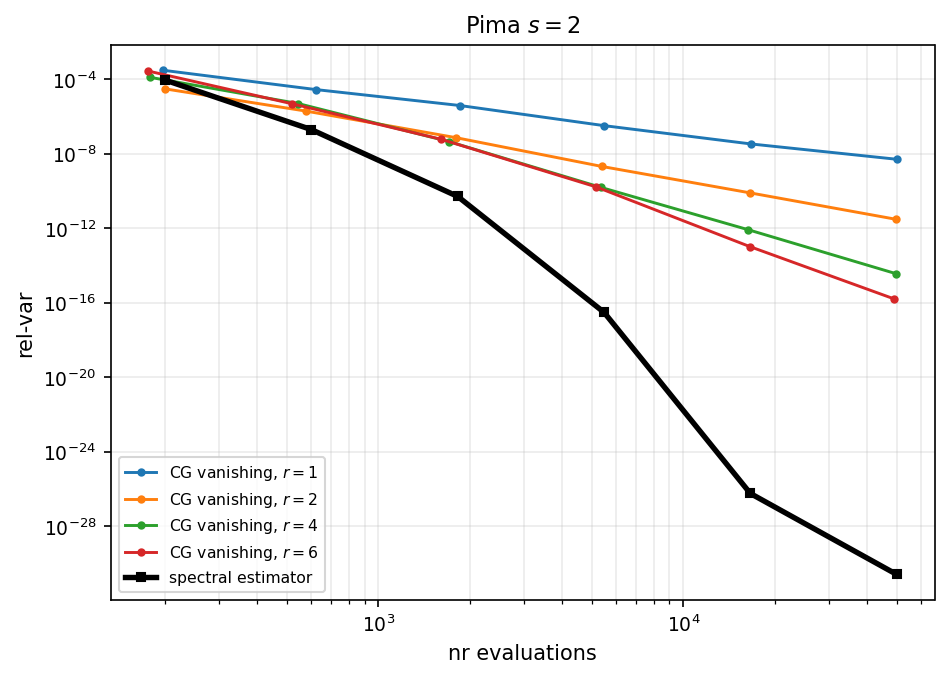

pima_results\pima4_lam1.5.png


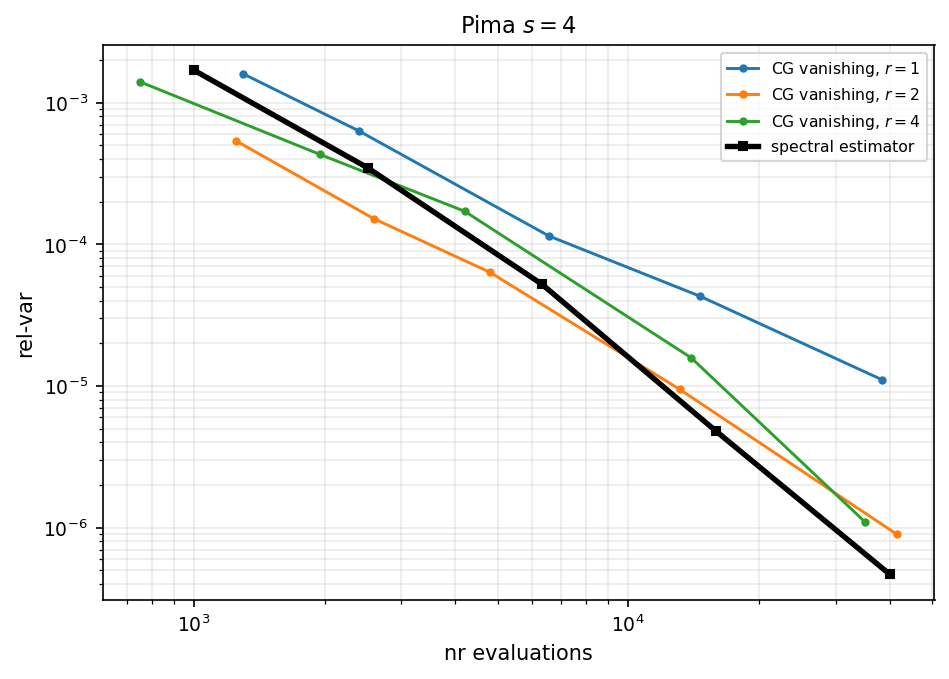

pima_results\pima4_lam3.0.png


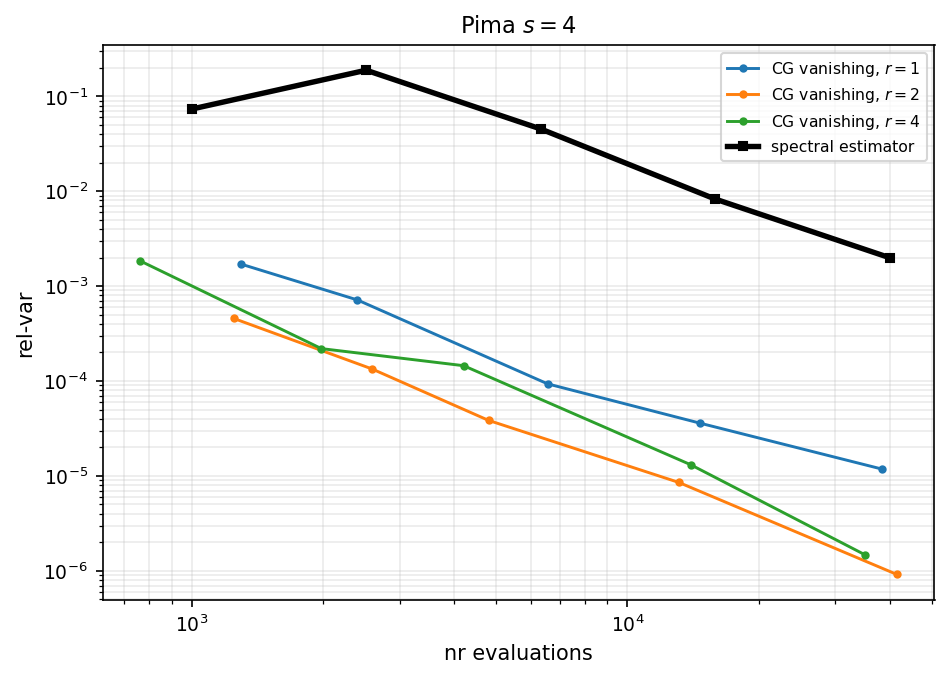


=== pima_results\pima2_lam1.5.csv ===


nevals,176,178,196,200,522,545,578,603,625,1606,...,16225,16487,16562,16571,16641,49009,49860,49928,50000,50176
row,,,,,,,,,,,,,,,,,,,,,
CG r=1,NaN,NaN,0.000314,NaN,NaN,NaN,NaN,NaN,0.000028,NaN,...,NaN,NaN,NaN,NaN,3.452700e-08,NaN,NaN,NaN,NaN,5.168000e-09
CG r=2,NaN,NaN,NaN,0.000031,NaN,NaN,0.000002,NaN,NaN,NaN,...,NaN,NaN,8.100000e-11,NaN,NaN,NaN,NaN,3.000000e-12,NaN,NaN
CG r=4,NaN,0.000131,NaN,NaN,NaN,0.000005,NaN,NaN,NaN,NaN,...,1.000000e-12,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
CG r=6,0.000282,NaN,NaN,NaN,0.000005,NaN,NaN,NaN,NaN,6.131500e-08,...,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
spectral,NaN,NaN,NaN,0.000092,NaN,NaN,NaN,2.025540e-07,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN


means: {'CG r=1': 0.075355, 'CG r=2': 0.075374, 'CG r=4': 0.075358, 'CG r=6': 0.075362, 'spectral': 0.075367}

=== pima_results\pima4_lam1.5.csv ===


nevals,753,1000,1250,1296,1950,2401,2515,2592,4201,4802,6325,6561,13122,13956,14641,15905,35141,38416,39999,41472
row,,,,,,,,,,,,,,,,,,,,
CG r=1,NaN,NaN,NaN,0.001601,NaN,0.00063,NaN,NaN,NaN,NaN,NaN,0.000115,NaN,NaN,0.000043,NaN,NaN,0.000011,NaN,NaN
CG r=2,NaN,NaN,0.000537,NaN,NaN,NaN,NaN,0.000152,NaN,0.000063,NaN,NaN,0.000009,NaN,NaN,NaN,NaN,NaN,NaN,8.998170e-07
CG r=4,0.001398,NaN,NaN,NaN,0.000431,NaN,NaN,NaN,0.000171,NaN,NaN,NaN,NaN,0.000016,NaN,NaN,0.000001,NaN,NaN,NaN
spectral,NaN,0.001693,NaN,NaN,NaN,NaN,0.000346,NaN,NaN,NaN,0.000052,NaN,NaN,NaN,NaN,0.000005,NaN,NaN,4.683470e-07,NaN


means: {'CG r=1': 0.021835, 'CG r=2': 0.021828, 'CG r=4': 0.021899, 'spectral': 0.021842}

=== pima_results\pima4_lam3.0.csv ===


nevals,763,1000,1250,1296,1985,2401,2515,2592,4209,4802,6325,6561,13122,13962,14641,15905,35119,38416,39999,41472
row,,,,,,,,,,,,,,,,,,,,
CG r=1,NaN,NaN,NaN,0.00171,NaN,0.000715,NaN,NaN,NaN,NaN,NaN,0.000093,NaN,NaN,0.000036,NaN,NaN,0.000012,NaN,NaN
CG r=2,NaN,NaN,0.000456,NaN,NaN,NaN,NaN,0.000134,NaN,0.000038,NaN,NaN,0.000009,NaN,NaN,NaN,NaN,NaN,NaN,9.170910e-07
CG r=4,0.001838,NaN,NaN,NaN,0.00022,NaN,NaN,NaN,0.000145,NaN,NaN,NaN,NaN,0.000013,NaN,NaN,0.000001,NaN,NaN,NaN
spectral,NaN,0.073339,NaN,NaN,NaN,NaN,0.188439,NaN,NaN,NaN,0.045283,NaN,NaN,NaN,NaN,0.008262,NaN,NaN,0.001989,NaN


means: {'CG r=1': 0.021813, 'CG r=2': 0.021832, 'CG r=4': 0.021914, 'spectral': 0.021935}


In [28]:
from IPython.display import Image, display
import pandas as pd, glob

for f in sorted(glob.glob('pima_results/*.png')):
    print(f); display(Image(f))

for f in sorted(glob.glob('pima_results/*.csv')):
    df = pd.read_csv(f)
    lab = df.apply(lambda r: 'spectral' if r['method'] == 'spectral'
                   else 'CG r=%d' % r['order'], axis=1)
    print('\n===', f, '===')
    display(df.assign(row=lab).pivot_table(index='row', columns='nevals',
                                           values='relvar').round(12))
    print('means:', df.groupby(lab)['mean'].mean().round(6).to_dict())